In [1]:
#data structures
import pandas as pd
import numpy as np

#machine learning

#metrics (performace and machine learning scores)
import time #used for seeing how long it takes to run programs

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [3]:
df = pd.read_csv('data/diabetes_012.csv') #The data values of each building
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


## Exploration of data:

In [5]:
featureList = df.drop(['Diabetes_012'], axis = 1).columns.tolist()

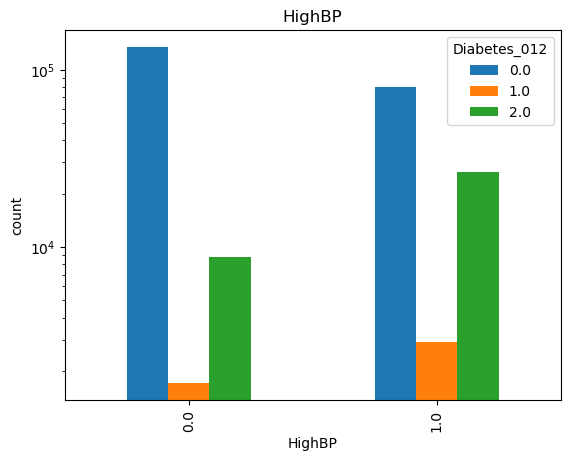

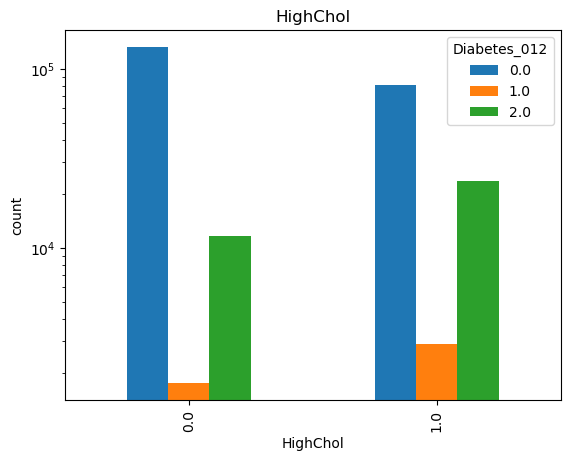

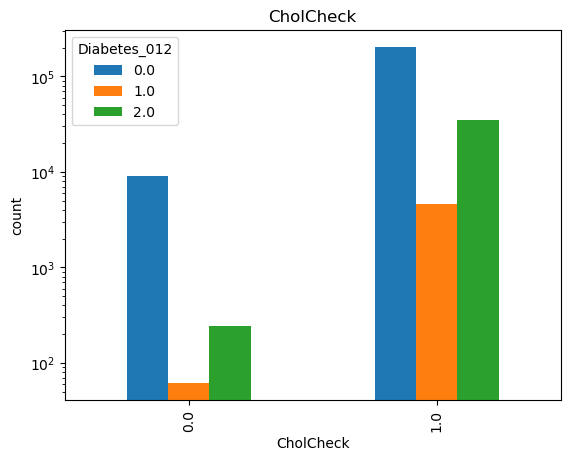

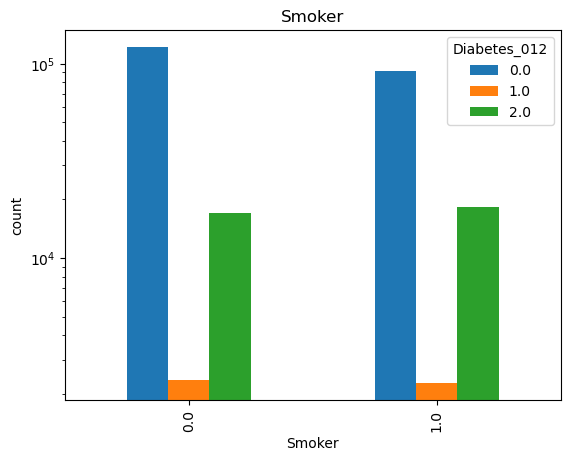

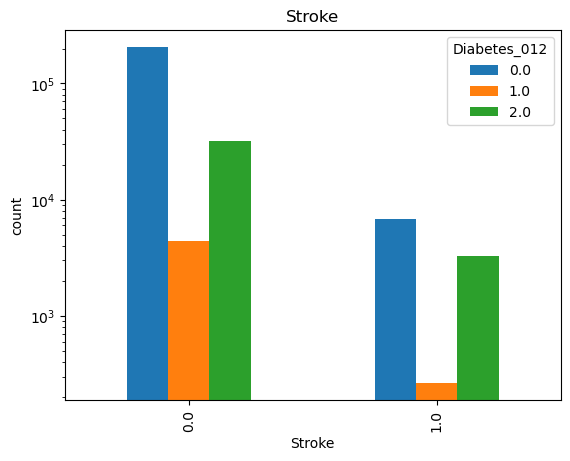

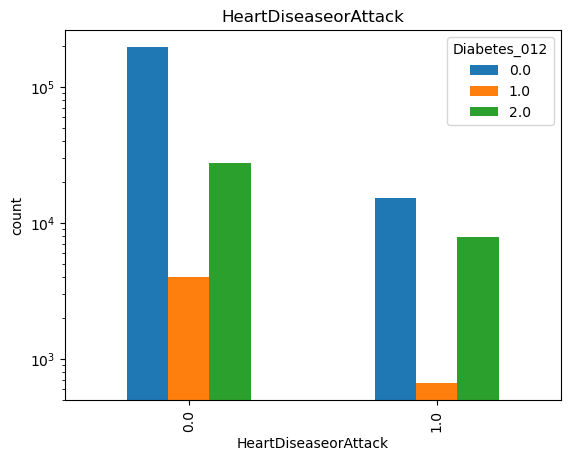

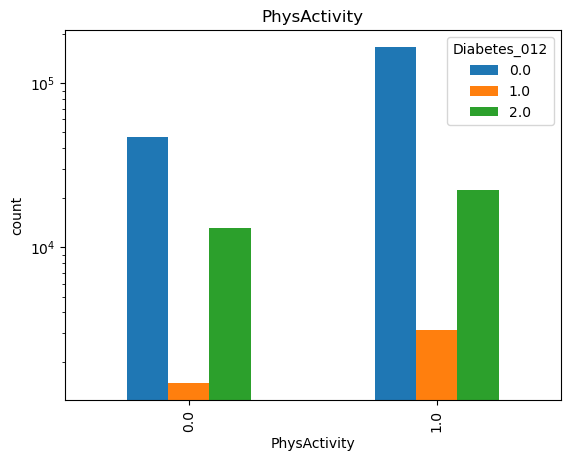

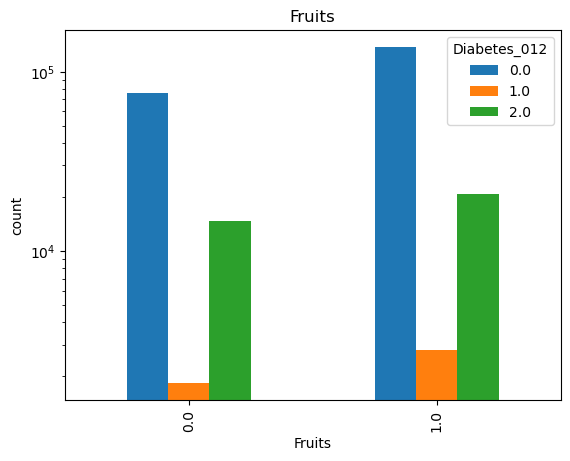

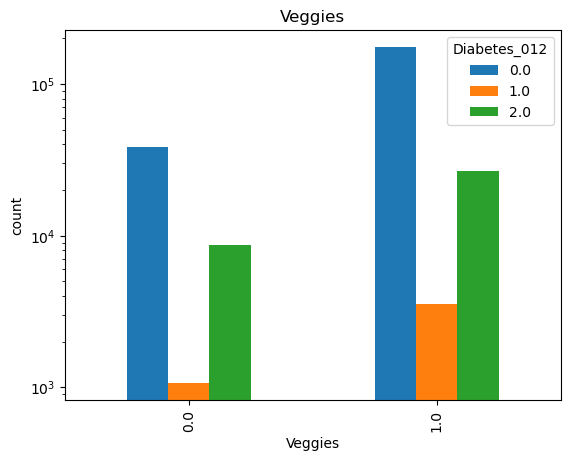

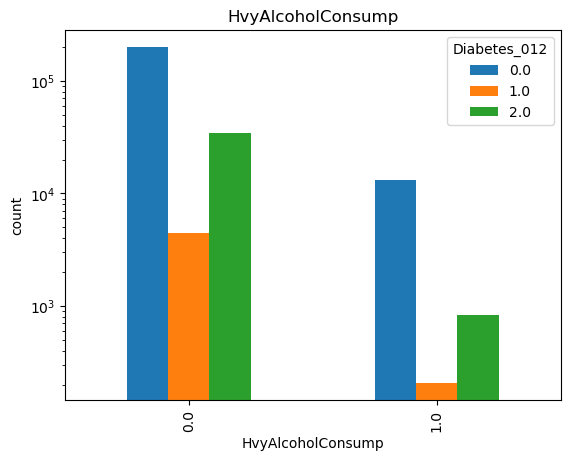

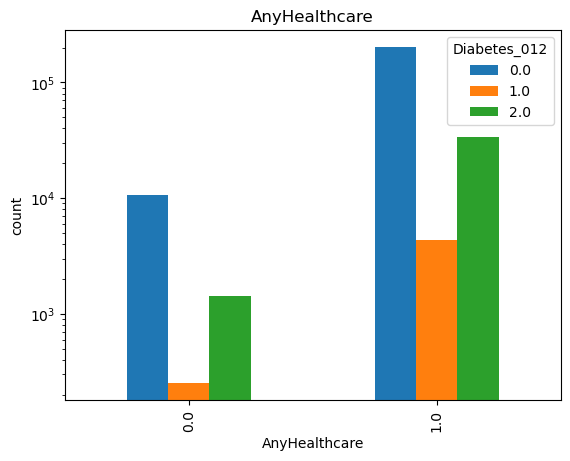

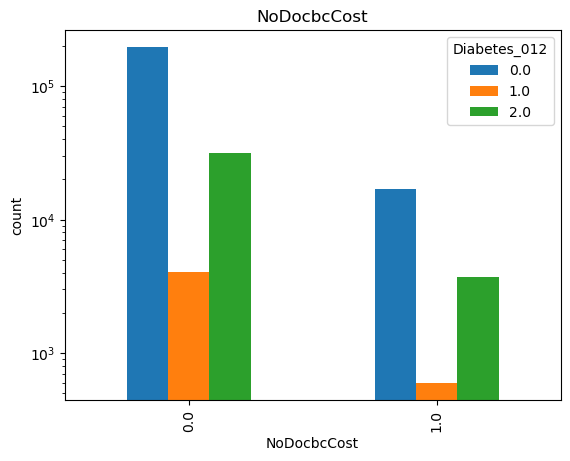

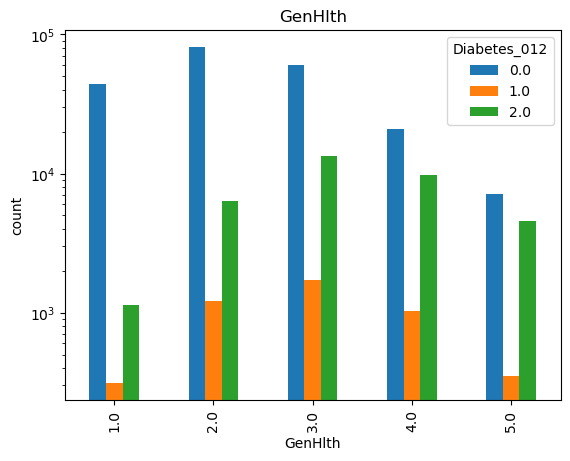

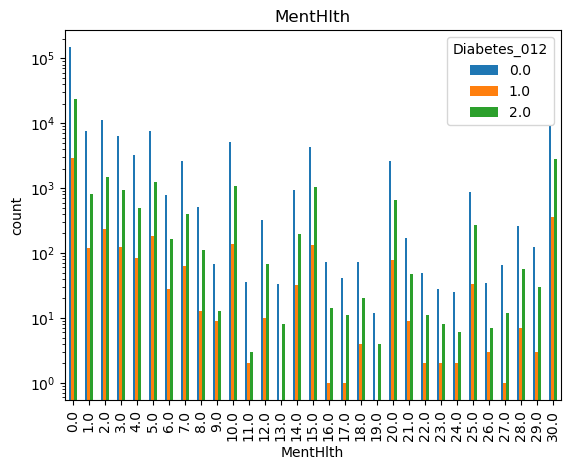

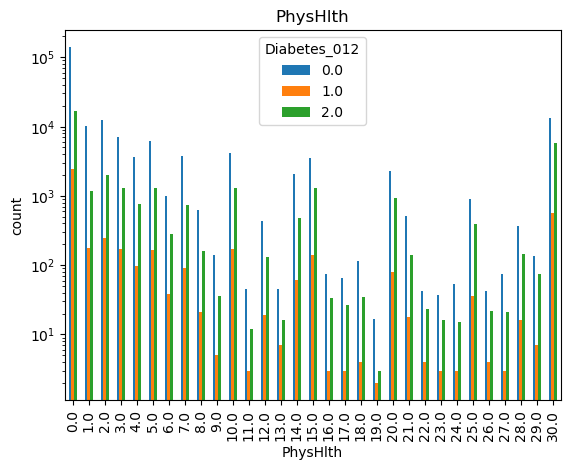

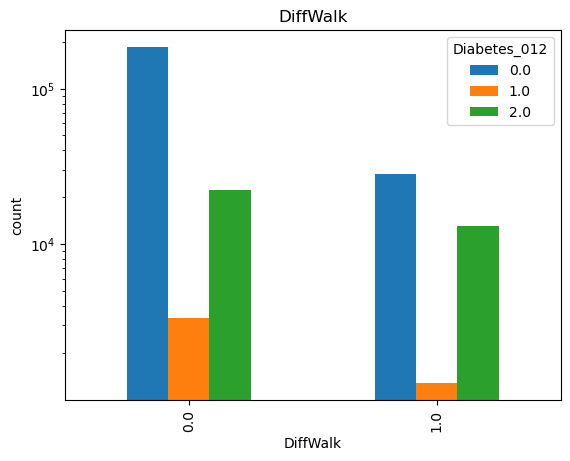

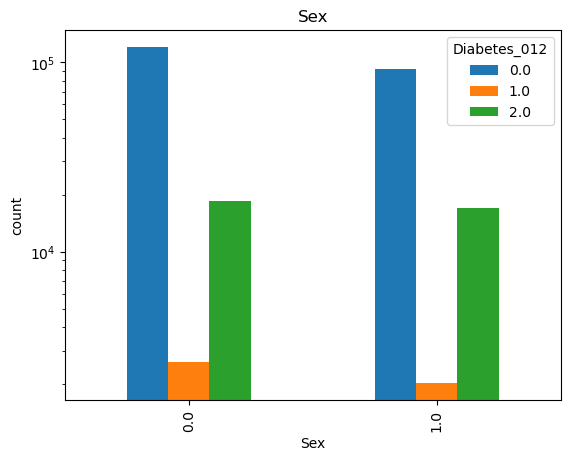

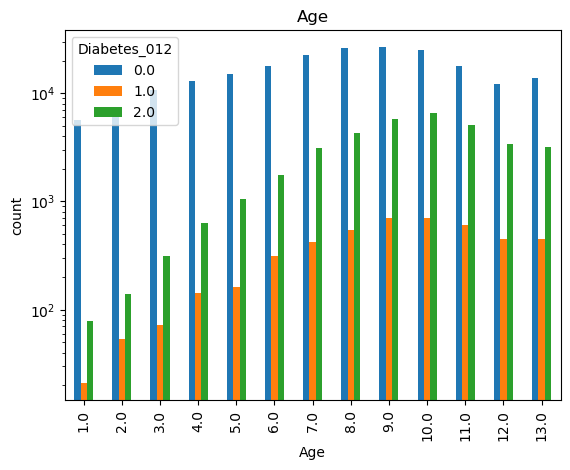

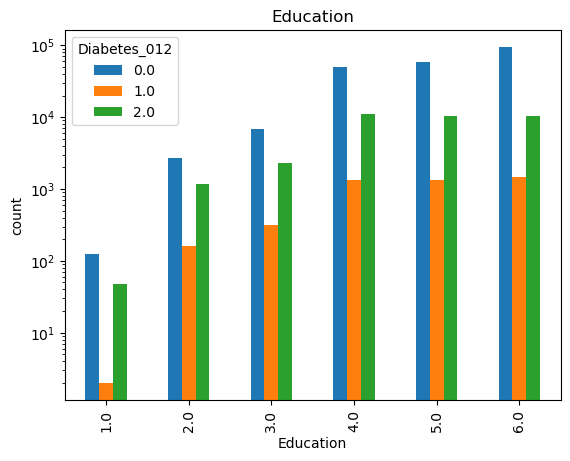

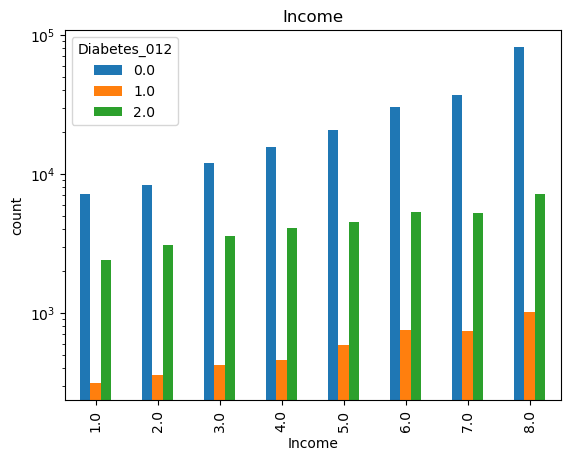

In [7]:
for column in featureList:
    data = df[['Diabetes_012', column]]
    g = data.groupby(['Diabetes_012', column])
    categoryTable = g.size().reset_index()
    categoryTable.columns = ['Diabetes_012', column, 'count']
    pivotTable = categoryTable.pivot(index = 'Diabetes_012', columns = column, values = 'count')
    pivotTable = pivotTable.fillna(0)
    # print(pivotTable)
    #plot if number of columns isn't too high
    numCol = len(pivotTable.columns)
    if(numCol < 32):
        pivotTable.T.plot(kind='bar')
        plt.title(column)
        plt.yscale('log')
        plt.ylabel('count')
        plt.show()